# California Wildfire Risk Prediction (with future projections)
**Model:** XGBoost Classifier  
**Grid:** 0.05° spatial resolution across California  
**Temporal:** Monthly, January 2012 – January 2025  
**Train:** Jan 2012 – Dec 2021 (10 years)  
**Test:** Jan 2022 – Jan 2025 (3 years)  
**Target:** `fire_occurred` (binary classification)

`fire_occured` is a binary classification and is 1 if there has been a fire in that cell in the month time period and is a 0 if there was no fire.

## 1. Setup & Install Dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

print('Libraries loaded.')

Libraries loaded.


## 2. Mount Google Drive & Set Data Paths
Upload your CSVs to Google Drive, then update `DATA_DIR` below.

In [4]:
FIRE_CSV      = "/content/drive/MyDrive/wildfire_project/data/ca_fire_monthly_2012_2025.csv"
WEATHER_CSV   = "/content/drive/MyDrive/wildfire_project/data/california_monthly_weather.csv"
ELEVATION_CSV = "/content/drive/MyDrive/wildfire_project/data/elevation_grid.csv"
NDVI_CSV      = "/content/drive/MyDrive/wildfire_project/data/ndvi.csv"
print('Paths configured.')

Paths configured.


## 3. Load Data

In [5]:
fire      = pd.read_csv(FIRE_CSV,      parse_dates=['year_month'])
weather   = pd.read_csv(WEATHER_CSV,   parse_dates=['year_month'])
elevation = pd.read_csv(ELEVATION_CSV)
ndvi      = pd.read_csv(NDVI_CSV,      parse_dates=['time'])
ndvi      = ndvi.rename(columns={'time': 'year_month'})

print(f'Fire      : {len(fire):,} rows')
print(f'Weather   : {len(weather):,} rows')
print(f'Elevation : {len(elevation):,} rows')
print(f'NDVI      : {len(ndvi):,} rows')

Fire      : 6,234,470 rows
Weather   : 4,834,368 rows
Elevation : 39,710 rows
NDVI      : 6,194,760 rows


## 4. Merge into a Single Feature Table

In [6]:
df = fire[['grid_id', 'year_month', 'lat', 'lon', 'fire_occurred', 'burned_area_m2']].copy()

weather_cols = ['grid_id', 'year_month',
                'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation']
df = df.merge(weather[weather_cols], on=['grid_id', 'year_month'], how='left')

elev_cols = ['grid_id', 'elevation_m', 'slope_deg', 'aspect_deg']
df = df.merge(elevation[elev_cols], on='grid_id', how='left')

ndvi_cols = ['grid_id', 'year_month', 'ndvi']
df = df.merge(ndvi[ndvi_cols], on=['grid_id', 'year_month'], how='left')

print(f'Merged shape: {df.shape}')
df.head(3)

Merged shape: (6234470, 15)


,grid_id,year_month,lat,lon,fire_occurred,burned_area_m2,temp_c,precip_mm,wind_speed_ms,soil_moisture,solar_radiation,elevation_m,slope_deg,aspect_deg,ndvi
0,000_000,2012-01-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN
1,000_000,2012-02-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN
2,000_000,2012-03-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN


## 5. Feature Engineering

In [7]:
df['month']       = df['year_month'].dt.month
df['year']        = df['year_month'].dt.year
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['fire_season'] = df['month'].between(6, 10).astype(int)
df['aspect_sin']  = np.sin(np.deg2rad(df['aspect_deg']))
df['aspect_cos']  = np.cos(np.deg2rad(df['aspect_deg']))

df = df.sort_values(['grid_id', 'year_month'])
for col in ['temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'ndvi']:
    df[f'{col}_lag1'] = df.groupby('grid_id')[col].shift(1)

df['precip_roll3'] = (
    df.groupby('grid_id')['precip_mm']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

print('Feature engineering complete.')
print(list(df.columns))

Feature engineering complete.
['grid_id', 'year_month', 'lat', 'lon', 'fire_occurred', 'burned_area_m2', 'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation', 'elevation_m', 'slope_deg', 'aspect_deg', 'ndvi', 'month', 'year', 'month_sin', 'month_cos', 'fire_season', 'aspect_sin', 'aspect_cos', 'temp_c_lag1', 'precip_mm_lag1', 'wind_speed_ms_lag1', 'soil_moisture_lag1', 'ndvi_lag1', 'precip_roll3']


## 6. Train / Test Split
Temporal split: **train ≤ 2021-12**, **test ≥ 2022-01**

In [8]:
TRAIN_END  = pd.Timestamp('2021-12-31')
TEST_START = pd.Timestamp('2022-01-01')

train_df = df[df['year_month'] <= TRAIN_END].copy()
test_df  = df[df['year_month'] >= TEST_START].copy()

print(f'Train: {train_df["year_month"].min().date()} to {train_df["year_month"].max().date()}  ({len(train_df):,} rows)')
print(f'Test : {test_df["year_month"].min().date()} to {test_df["year_month"].max().date()}  ({len(test_df):,} rows)')
print(f'Fire rate -- train: {train_df["fire_occurred"].mean():.4%} | test: {test_df["fire_occurred"].mean():.4%}')

Train: 2012-01-01 to 2021-12-01  (4,765,200 rows)
Test : 2022-01-01 to 2025-01-01  (1,469,270 rows)
Fire rate -- train: 0.0472% | test: 0.0189%


In [9]:
FEATURES = [
    'lat', 'lon',
    'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation',
    'elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos',
    'ndvi',
    'month_sin', 'month_cos', 'fire_season', 'year',
    'temp_c_lag1', 'precip_mm_lag1', 'wind_speed_ms_lag1',
    'soil_moisture_lag1', 'ndvi_lag1', 'precip_roll3',
]
TARGET = 'fire_occurred'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Features : {len(FEATURES)}')
print(f'Train NaN: {X_train.isna().mean().mean():.2%}')
print(f'Test  NaN: {X_test.isna().mean().mean():.2%}')

Features : 22
Train NaN: 17.91%
Test  NaN: 17.81%


## 7. Load XGBoost Model

In [10]:
import joblib, json

model    = joblib.load('/content/drive/MyDrive/wildfire_project/model/wildfire_xgb.joblib')
with open('/content/drive/MyDrive/wildfire_project/model/feature_list.json') as f:
    loaded_features = json.load(f)

print('Model loaded. Features:', loaded_features[:5], '...')

Model loaded. Features: ['lat', 'lon', 'temp_c', 'precip_mm', 'wind_speed_ms'] ...


## 8. Predict Fire Risk for a Recent Year (2024)

In [11]:
PREDICT_YEAR = 2024

predict_df    = df[df['year'] == PREDICT_YEAR].copy()
predict_clean = predict_df.dropna(subset=FEATURES).copy()
print(f'Rows for {PREDICT_YEAR}: {len(predict_df):,}  (after dropna: {len(predict_clean):,})')

predict_clean['fire_risk_prob'] = model.predict_proba(predict_clean[FEATURES])[:, 1]
predict_clean[['grid_id','year_month','lat','lon','fire_risk_prob']].head(5)

Rows for 2024: 476,520  (after dropna: 199,379)


,grid_id,year_month,lat,lon,fire_risk_prob
89163,002_149,2024-01-01,32.625,-117.025,0.003042
89164,002_149,2024-02-01,32.625,-117.025,0.002146
89165,002_149,2024-03-01,32.625,-117.025,0.002157
89166,002_149,2024-04-01,32.625,-117.025,0.002248
89167,002_149,2024-05-01,32.625,-117.025,0.002908


### Parameters

*predict_clean : pd.DataFrame* -
Must contain:
['month', 'lat', 'lon', 'fire_risk_prob']

*year : int* -
Year for title.

*months : list[int] or None* -
Months to render (e.g. [6,7,8,9]).
If None, plots all available months.

*ncols : int* -
Number of subplot columns.

*figsize_per_row : int* -
Height of each row in inches.

*save_path : str or None* -
Optional path to save figure.

*use_cbar : bool* -
display the risk color bar


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fire_risk_months(
    predict_clean,
    year,
    months=None,
    ncols=4,
    figsize_per_row=4,
    save_path=None,
    use_cbar=False,
    top_n=None,
    show_base=True,
    show_top=True,
    top_n_color='purple',
):
    month_names = [
        'Jan','Feb','Mar','Apr','May','Jun',
        'Jul','Aug','Sep','Oct','Nov','Dec'
    ]
    if months is None:
        months = sorted(predict_clean['month'].unique())
    months = sorted(months)
    nrows = int(np.ceil(len(months) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, figsize_per_row * nrows)
    )
    if len(months) == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    sc = None
    for i, m in enumerate(months):
        sub = predict_clean[predict_clean['month'] == m].copy()

        if show_base:
            sc = axes[i].scatter(
                sub['lon'],
                sub['lat'],
                c=sub['fire_risk_prob'],
                cmap='YlOrRd',
                vmin=0,
                vmax=1,
                s=2,
                linewidths=0,
                zorder=1
            )
        elif not show_base and top_n is None:
            sc = axes[i].scatter(
                sub['lon'],
                sub['lat'],
                c=sub['fire_risk_prob'],
                cmap='YlOrRd',
                vmin=0,
                vmax=1,
                s=2,
                linewidths=0,
                zorder=1
            )

        if top_n is not None and show_top:
            cutoff = sub['fire_risk_prob'].quantile(1 - top_n)
            top = sub[sub['fire_risk_prob'] >= cutoff]
            axes[i].scatter(
                top['lon'],
                top['lat'],
                c=top_n_color,
                s=2,
                linewidths=0,
                zorder=2,
                label=f'Top {int(top_n*100)}%' if i == 0 else None,
            )

        axes[i].set_title(
            f'{month_names[m-1]} {year}'
            + (f' (top {int(top_n*100)}%)' if top_n is not None else ''),
            fontsize=10
        )
        axes[i].set_aspect('equal')
        axes[i].tick_params(labelsize=6)

    for j in range(len(months), len(axes)):
        axes[j].set_visible(False)

    if use_cbar and sc is not None:
        cbar = fig.colorbar(sc, ax=axes[:len(months)], shrink=0.7)
        cbar.set_label('Fire Risk Probability')

    if top_n is not None and show_top:
        axes[0].legend(fontsize=7, loc='lower left', markerscale=1.5)

    fig.suptitle(
        f'California Wildfire Risk — {year}'
        + (f' | Top {int(top_n*100)}% highest risk' if top_n is not None else ''),
        fontsize=14
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

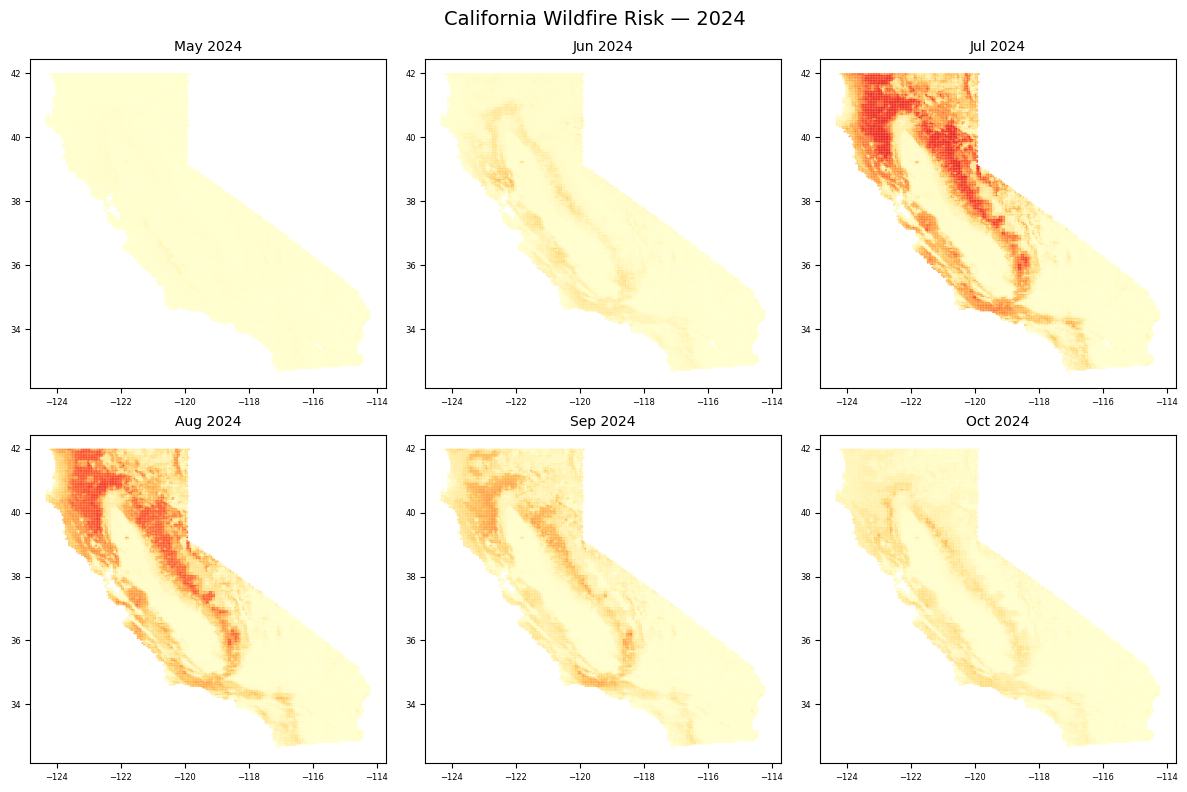

In [13]:
plot_fire_risk_months(
    predict_clean,
    year=2024,
    months=[5, 6, 7, 8, 9, 10],
    ncols=3
)

In [14]:
out_cols = ['grid_id', 'year_month', 'lat', 'lon', 'month', 'fire_occurred', 'fire_risk_prob']
out_path = f'/content/drive/MyDrive/wildfire_project/output/fire_risk_predictions_{PREDICT_YEAR}.csv'
predict_clean[out_cols].to_csv(out_path, index=False)
print(f'Predictions saved: {out_path}')

Predictions saved: /content/drive/MyDrive/wildfire_project/output/fire_risk_predictions_2024.csv


## 9. Climate Change Risk Shift

We used IPCC AR6 trends for climate change predictions to see how the wildfire risk will shift in the next 10-50 years.

Climate adjustments applied (per decade):

| Variable | Change per decade | Rationale |
|---|---|---|
| `temp_c` | +0.5 °C | IPCC AR6: ~1–2 °C warmer by 2050 for CA |
| `precip_mm` | −3% | CA models: drier summers |
| `soil_moisture` | −2% | Follows precip + increased evaporation |
| `ndvi` | −1% | Vegetation stress under heat/drought |

Lag features are shifted by the same amounts for a consistent scenario.

In [15]:
DELTA_TEMP_PER_DECADE        = +0.5
DELTA_PRECIP_FRAC_PER_DECADE = -0.03
DELTA_SOIL_FRAC_PER_DECADE   = -0.02
DELTA_NDVI_FRAC_PER_DECADE   = -0.01

HORIZONS = {
    '10 years (2035)': 1,
    '25 years (2050)': 2.5,
    '50 years (2075)': 5,
}

BASELINE_YEAR   = 2024
BASELINE_MONTHS = [6, 7, 8, 9]

baseline = predict_clean[
    (predict_clean['year'] == BASELINE_YEAR) &
    (predict_clean['month'].isin(BASELINE_MONTHS))
].copy()

print(f'Baseline rows: {len(baseline):,}  ({BASELINE_YEAR}, months {BASELINE_MONTHS})')


Baseline rows: 66,449  (2024, months [6, 7, 8, 9])


In [16]:
scenario_results = {}

for label, decades in HORIZONS.items():
    fut = baseline.copy()

    for col in ['temp_c', 'temp_c_lag1']:
        if col in fut.columns:
            fut[col] = fut[col] + DELTA_TEMP_PER_DECADE * decades

    for col in ['precip_mm', 'precip_mm_lag1', 'precip_roll3']:
        if col in fut.columns:
            fut[col] = fut[col] * (1 + DELTA_PRECIP_FRAC_PER_DECADE * decades)

    for col in ['soil_moisture', 'soil_moisture_lag1']:
        if col in fut.columns:
            fut[col] = fut[col] * (1 + DELTA_SOIL_FRAC_PER_DECADE * decades)

    for col in ['ndvi', 'ndvi_lag1']:
        if col in fut.columns:
            fut[col] = fut[col] * (1 + DELTA_NDVI_FRAC_PER_DECADE * decades)

    fut['future_risk_prob'] = model.predict_proba(fut[FEATURES])[:, 1]
    fut['risk_delta']       = fut['future_risk_prob'] - fut['fire_risk_prob']

    per_cell = (
        fut.groupby(['grid_id', 'lat', 'lon'])
           [['fire_risk_prob', 'future_risk_prob', 'risk_delta']]
           .mean()
           .reset_index()
    )
    scenario_results[label] = per_cell
    pct_up = (per_cell['risk_delta'] > 0).mean() * 100
    print(f'{label}: avg delta = {per_cell["risk_delta"].mean():.4f}  | {pct_up:.0f}% of cells increasing')


10 years (2035): avg delta = 0.0037  | 48% of cells increasing
25 years (2050): avg delta = 0.0084  | 48% of cells increasing
50 years (2075): avg delta = 0.0140  | 44% of cells increasing


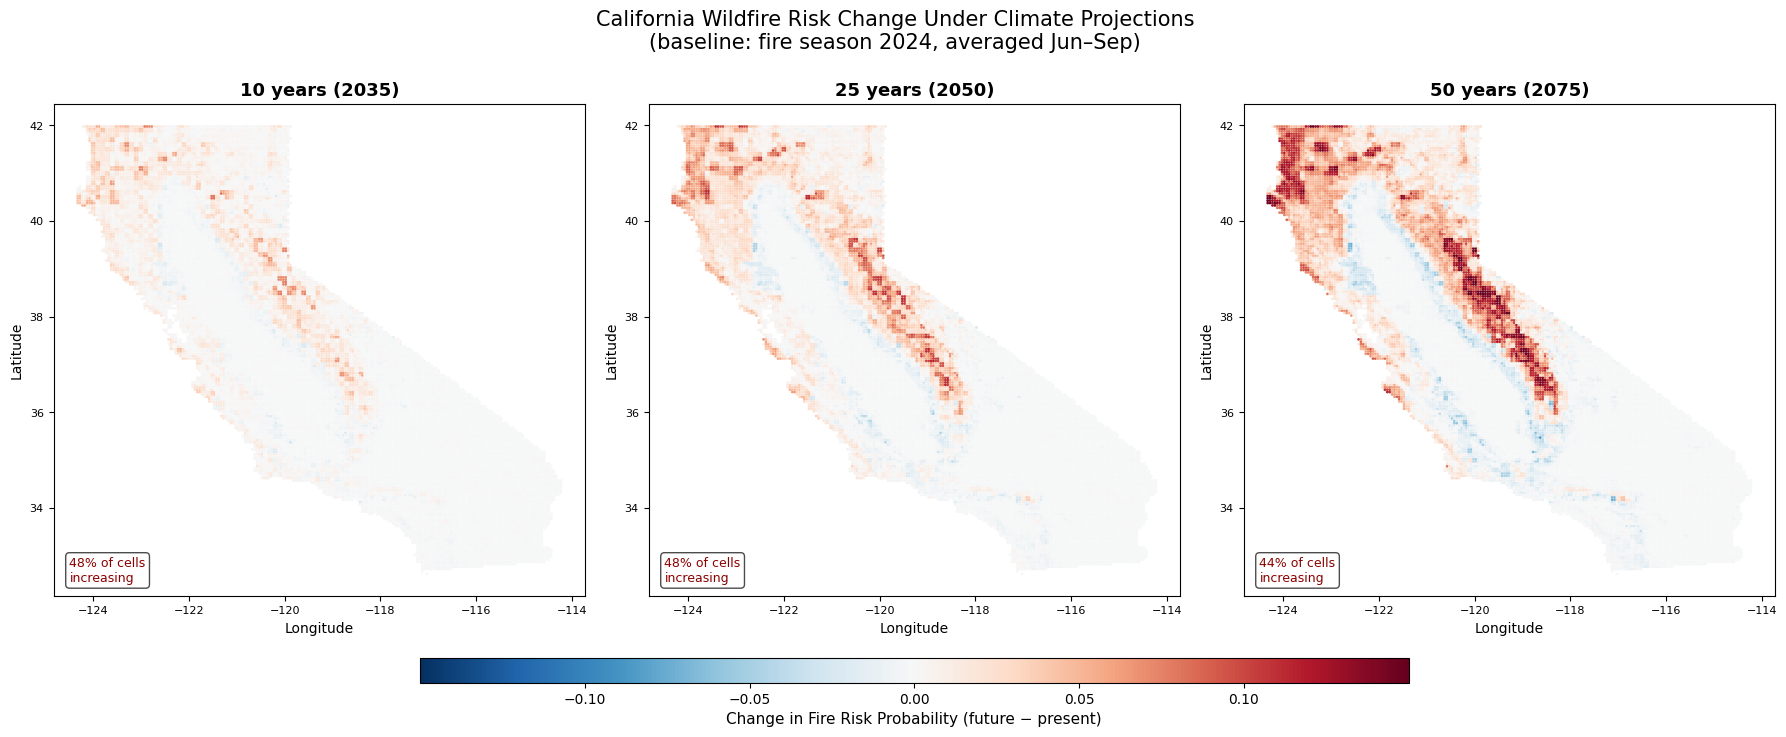

Map saved.


In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 8))

cmap   = plt.cm.RdBu_r
vlimit = 0.15
norm   = mcolors.TwoSlopeNorm(vmin=-vlimit, vcenter=0, vmax=vlimit)

sc = None
for ax, (label, per_cell) in zip(axes, scenario_results.items()):
    sc = ax.scatter(
        per_cell['lon'], per_cell['lat'],
        c=per_cell['risk_delta'],
        cmap=cmap, norm=norm,
        s=4, linewidths=0
    )
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

    pct_up = (per_cell['risk_delta'] > 0).mean() * 100
    ax.annotate(
        f'{pct_up:.0f}% of cells\nincreasing',
        xy=(0.03, 0.03), xycoords='axes fraction', fontsize=9, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )

plt.tight_layout(rect=[0, 0.12, 1, 0.93])

cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='horizontal',
    fraction=0.04,
    pad=0.1,
    aspect=40
)
cbar.set_label('Change in Fire Risk Probability (future − present)', fontsize=11)

fig.suptitle(
    'California Wildfire Risk Change Under Climate Projections\n'
    f'(baseline: fire season {BASELINE_YEAR}, averaged Jun–Sep)',
    fontsize=15
)
plt.savefig(
    '/content/drive/MyDrive/wildfire_project/output/climate_risk_shift.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Map saved.')

In [18]:

for label, per_cell in scenario_results.items():
    safe_label = label.replace(' ', '_').replace('(', '').replace(')', '')
    out_path = (
        '/content/drive/MyDrive/wildfire_project/output/'
        f'climate_risk_delta_{safe_label}.csv'
    )
    per_cell.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')


Saved: /content/drive/MyDrive/wildfire_project/output/climate_risk_delta_10_years_2035.csv
Saved: /content/drive/MyDrive/wildfire_project/output/climate_risk_delta_25_years_2050.csv
Saved: /content/drive/MyDrive/wildfire_project/output/climate_risk_delta_50_years_2075.csv
